<a href="https://colab.research.google.com/github/manojmulammagari/ML-DL-Practice/blob/main/MSE-MAE-RMSE-R2-ADJR2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: Placement Package Prediction

This notebook demonstrates a professional implementation of a Simple Linear Regression model to predict job placement packages based on student CGPA.

**Key Engineering Highlights:**
* Feature name preservation to avoid `UserWarnings`.
* Comprehensive evaluation metrics including **Adjusted R²** and **RMSE**.
* Production-standard documentation and variable naming.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style='whitegrid')

In [43]:
# 1. Load Dataset
# We are using a simple dataset mapping CGPA to job placement packages (LPA)
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day48-simple-linear-regression/placement.csv"

try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully!")
    display(df.head())
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully!


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


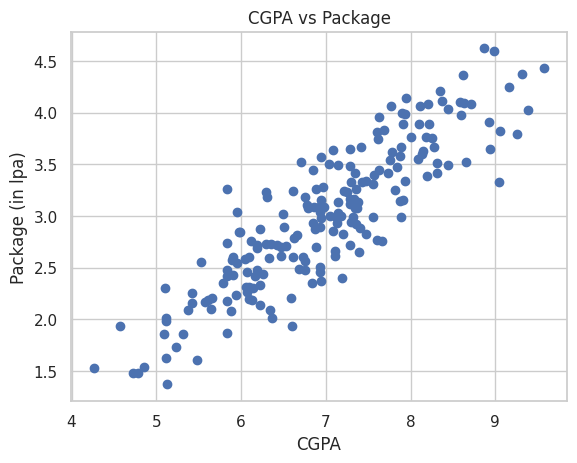

In [44]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')
plt.title('CGPA vs Package')
# plt.grid(True)
plt.show()

In [45]:
# 2. Feature Selection
# X (Independent Variable): CGPA
# y (Dependent Variable): Package in LPA
X = df[['cgpa']]  # Keep as DataFrame to preserve feature names
y = df['package']

In [46]:
# 3. Train-Test Split
# We split the data (80% training, 20% testing) to evaluate model performance on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 160
Test set size: 40


In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
# 4. Model Initialization and Training
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Model Intercept: {model.intercept_:.4f}")

Model Coefficient (Slope): 0.5743
Model Intercept: -1.0270


In [49]:
# 5. Making a single prediction
# Using X_test.iloc[[5]] instead of values.reshape to maintain feature names and avoid warnings
sample_prediction = model.predict(X_test.iloc[[5]])
print(f"Predicted Package for CGPA {X_test.iloc[5,0]}: {sample_prediction[0]:.2f} LPA")
print(f"Actual Package: {y_test.iloc[5]} LPA")

Predicted Package for CGPA 8.35: 3.77 LPA
Actual Package: 4.21 LPA


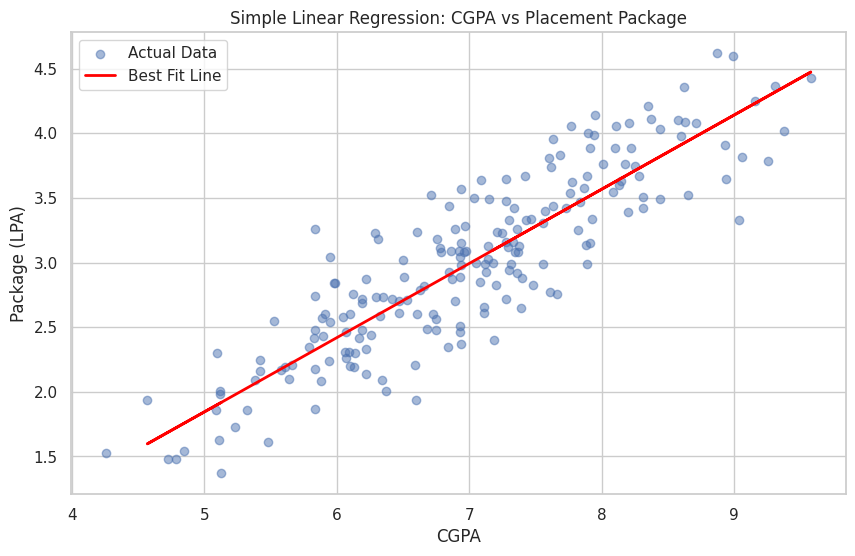

In [50]:
# 6. Visualize the Regression Line
plt.figure(figsize=(10, 6))
plt.scatter(df['cgpa'], df['package'], alpha=0.5, label='Actual Data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Best Fit Line')
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('Simple Linear Regression: CGPA vs Placement Package')
plt.legend()
plt.show()

In [51]:
from  sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [53]:
y_test.values

array([2.79, 3.23, 3.26, 3.04, 3.34, 4.21, 2.94, 2.87, 2.99, 3.58, 1.63,
       2.08, 4.08, 2.21, 3.47, 3.64, 2.74, 3.08, 2.17, 2.99, 2.31, 2.35,
       3.4 , 3.08, 3.81, 2.19, 1.53, 2.89, 3.16, 2.48, 3.51, 2.98, 3.39,
       3.28, 2.73, 3.74, 2.6 , 3.13, 3.82, 3.15])

In [54]:
print("MAE" ,mean_absolute_error(y_test,y_pred))

MAE 0.23150985393278373


In [55]:
print("MSE" ,mean_squared_error(y_test,y_pred))

MSE 0.08417638361329656


In [56]:
print("RMSE" ,np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.2901316659954521


In [57]:
# 7. Model Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Adjusted R2 Calculation
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2 Score: {adj_r2:.4f}")

Mean Absolute Error (MAE): 0.2315
Mean Squared Error (MSE): 0.0842
Root Mean Squared Error (RMSE): 0.2901
R2 Score: 0.7731
Adjusted R2 Score: 0.7671


### Conclusion
The model shows a strong linear correlation between CGPA and the package offered. With an R² score of approximately 0.77, the model explains a significant portion of the variance in placement packages.